In [1]:
import collections as clt
import itertools as it
import functools as ft
import operator as op
import pathlib as P
import pickle

In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.cm as cm

In [3]:
ns = ["cc", "mf", "bp"]
ontology_lst = ["cellular_component", "molecular_function", "biological_process"]

In [4]:
msq_pth = P.Path("/data0/shaojiangyi/pprogo-flg-1/data/mmseq_sim_csr.npz")
msq_mat = sp.load_npz(msq_pth)

In [5]:
msq_mat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 52583671 stored elements and shape (124073, 124073)>

In [6]:
data_path = [f"/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/{x}_data.pkl"
             for x in ["train", "valid", "test"]]
prot_data = pd.concat([pd.read_pickle(x) for x in data_path], ignore_index=True)

In [7]:
# load go term data
count_ic_path = "/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/term_counts_with_position-111.pkl"
term_count_ic = pd.read_pickle(count_ic_path)

In [8]:
prot_names = prot_data["proteins"].unique()

In [9]:
# load protein name
pname_path = "/data0/shaojiangyi/pprogo-flg-1/data/protein_name.txt"
with open(pname_path, "r") as f:
    prot_names = [x.strip() for x in f.readlines()]

In [10]:
# load go term list
root_path = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = root_path / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)

In [11]:
namespace_terms = dict(zip(ontology_lst, curr_labels))
nspace_ti = {k: {x: i for i, x in enumerate(v)}
             for k, v in namespace_terms.items()}

In [12]:
# load protein-go label data
root_path = P.Path("/data0/shaojiangyi/pprogo-flg-1/data")
prot_labels = []
for n in ns:
    y_label = root_path / n / "label.pkl"
    with open(y_label, "rb") as f:
        labels = pickle.load(f)
    tmp = clt.defaultdict(list)
    for k, v in zip(labels["protein"], labels["go"]):
        tmp[k].append(v)
    prot_labels.append(tmp)

In [13]:
list(prot_labels[0].items())[:2]

[(0, [1359, 1816]), (3, [314, 142, 1816])]

In [14]:
# convert protein idx and label idx to protein name and go term respectively
for i, n in enumerate(ontology_lst):
    prot_labels[i] = {
        prot_names[k]: [namespace_terms[n][x] for x in v]
        for k, v in prot_labels[i].items()
    }

In [15]:
list(prot_labels[0].items())[:2]

[('Q5BHH6', ['GO:0005576', 'GO:0110165']),
 ('C8VRD6', ['GO:0005575', 'GO:0005622', 'GO:0110165'])]

In [16]:
# build a mapping from protein to its go terms
prot_labels = ft.reduce(
    op.or_, [clt.defaultdict(list, x) for x in prot_labels]
)

In [17]:
# convert to pandas dataframe
prot_labels_df = pd.DataFrame({
    "proteins": list(prot_labels.keys()),
    "go_terms": [x for x in prot_labels.values()]
})

In [18]:
prot_labels_df

,proteins,go_terms
0,Q5BHH6,"[GO:0005576, GO:0110165]"
1,C8VRD6,"[GO:0005575, GO:0005622, GO:0110165]"
2,Q5BH26,"[GO:0031981, GO:0005634, GO:0140535, GO:004323..."
3,C8VUY4,"[GO:0010033, GO:0071396, GO:0070887, GO:000998..."
4,C8VUB6,"[GO:0005575, GO:0005576, GO:0110165]"
...,...,...
124068,Q96DC8,"[GO:0010243, GO:0070887, GO:0048584, GO:190165..."
124069,Q9VAM6,"[GO:0050801, GO:0006873, GO:0030003, GO:000998..."
124070,Q9VNF9,"[GO:1905952, GO:0051179, GO:0048518, GO:190595..."
124071,Q9VT33,"[GO:0007610, GO:0050896, GO:0042048, GO:000763..."


In [19]:
# calculate the degree of each protein 
# the msq_mat is a sparse matrix where the score denote the mmseqs identity score
# when calculating the degree, all the scores are considered as 1

# copy a matrix where the scores are all 1
msq_mat_deg = msq_mat.copy()
msq_mat_deg.data = np.ones_like(msq_mat_deg.data)
# calculate the indegree of each protein
prot_deg = msq_mat_deg.sum(axis=0).A1

# create a dataframe with the protein names and their degrees
prot_deg_df = pd.DataFrame({
    "proteins": prot_names,
    "indegree": prot_deg
}).astype({"proteins": str, "indegree": int})

In [20]:
# calculate the IC (information content) based on the degree
# first get all the number of triangular edges in the matrix
num_prots = len(prot_names)
prot_deg_df["ic"] = np.log2(num_prots / prot_deg_df["indegree"])

In [21]:
prot_deg_df

,proteins,indegree,ic
0,Q5BHH6,289,8.745904
1,Q5BGS1,363,8.417004
2,Q5BHC4,420,8.206584
3,C8VRD6,383,8.339629
4,Q5BG78,147,9.721157
...,...,...,...
124068,Q96DC8,305,8.668164
124069,Q9VAM6,274,8.822798
124070,Q9VNF9,392,8.306120
124071,Q9VT33,362,8.420984


In [22]:
np.quantile(prot_deg_df["ic"], np.linspace(0, 1, 21, endpoint=False))

array([4.33704172, 7.24840433, 7.54579024, 7.70894138, 7.83602129,
       7.94641508, 8.03818662, 8.11992977, 8.18951064, 8.24840433,
       8.30611983, 8.35858725, 8.40907702, 8.46139806, 8.51143874,
       8.56768285, 8.63542745, 8.74092058, 8.90402139, 9.26261819,
       9.97831517])

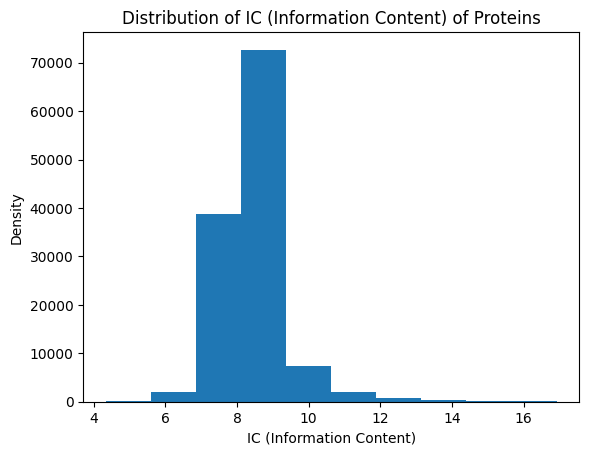

In [23]:
# simply show the distribution of IC protein
idx = prot_deg_df["ic"] != np.inf
plt.hist(prot_deg_df.loc[idx, "ic"])
plt.xlabel("IC (Information Content)")
plt.ylabel("Density")
plt.title("Distribution of IC (Information Content) of Proteins")
plt.show()

In [24]:
termic_dict = term_count_ic.set_index("gos")["ic"].to_dict()
protic_dict = prot_deg_df.set_index("proteins")["ic"].to_dict()

In [25]:
# for plotting, proteins, gos, p_ic, g_ic
prot_go_ic = clt.defaultdict(list)
for p, g in prot_labels.items():
    for go in g:
        prot_go_ic["proteins"].append(p)
        prot_go_ic["gos"].append(go)
        prot_go_ic["p_ic"].append(protic_dict[p])
        prot_go_ic["g_ic"].append(termic_dict[go])
prot_go_ic_df = pd.DataFrame(prot_go_ic) 

In [26]:
term_count_ic

,gos,counts,ic,position,maxdep,lgst
0,GO:0005950,6,13.755931,Deep,5,5
1,GO:0031436,4,14.340893,Deep,9,9
2,GO:0044614,13,12.640454,Deep,10,10
3,GO:0098894,2,15.340893,Deep,9,9
4,GO:0032991,17284,2.263744,Shallow,15,2
...,...,...,...,...,...,...
31310,GO:0006144,74,10.271132,Deep,10,8
31311,GO:0072092,3,14.895623,Deep,16,16
31312,GO:0030509,406,7.815249,Medium,19,9
31313,GO:0008627,14,12.673230,Deep,11,8


In [27]:
prot_go_ic_df

,proteins,gos,p_ic,g_ic
0,Q5BHH6,GO:0005576,8.745904,3.863894
1,Q5BHH6,GO:0110165,8.745904,0.024682
2,C8VRD6,GO:0005575,8.339629,0.000017
3,C8VRD6,GO:0005622,8.339629,0.361155
4,C8VRD6,GO:0110165,8.339629,0.024682
...,...,...,...,...
4918484,Q9Z0V9,GO:1903506,9.876436,3.226885
4918485,Q9Z0V9,GO:0009889,9.876436,2.916912
4918486,Q9Z0V9,GO:0031323,9.876436,2.423693
4918487,Q9Z0V9,GO:1903508,9.876436,4.422932


Creating hexbin plots...
Creating plot for Shallow position...


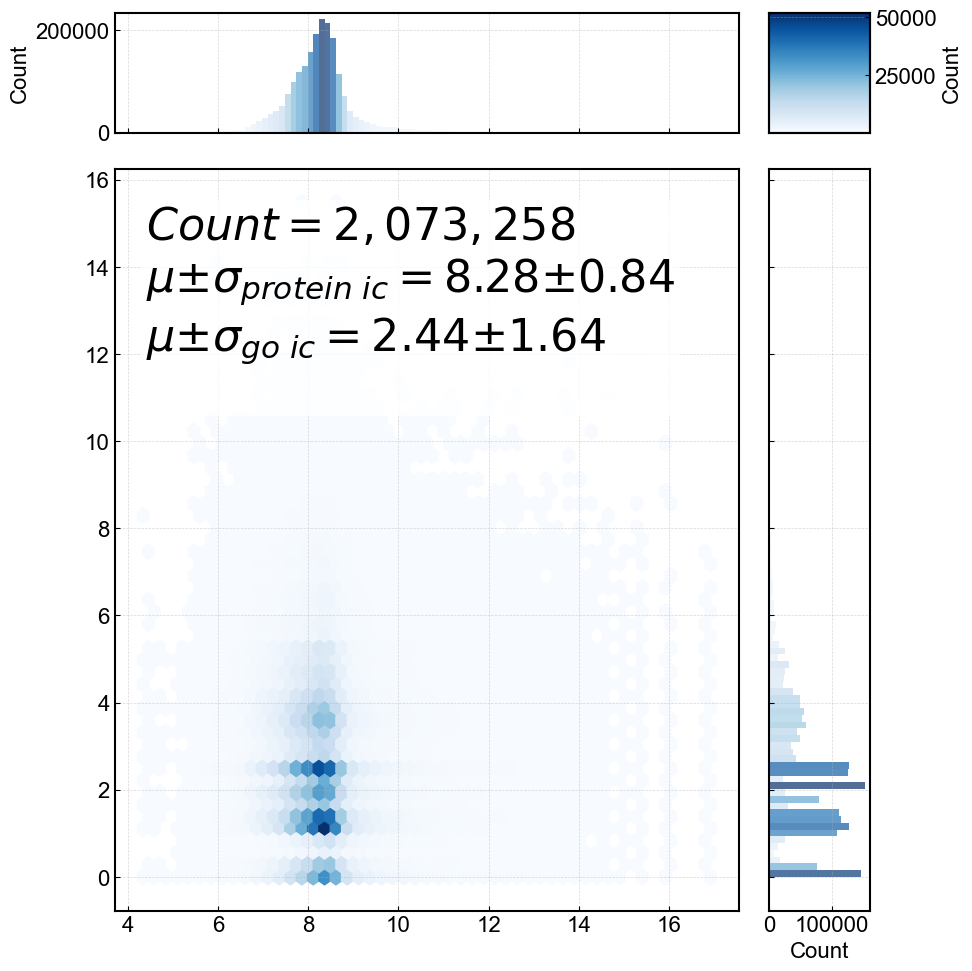

Creating plot for Medium position...


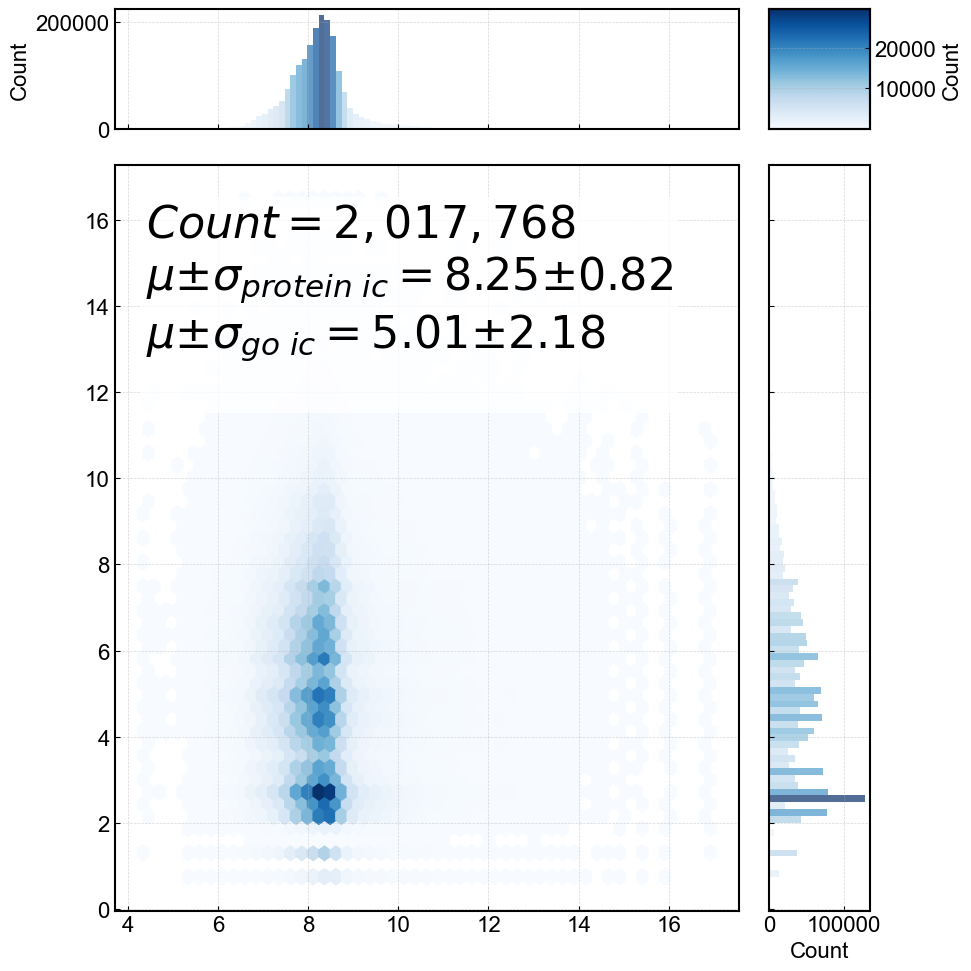

Creating plot for Deep position...


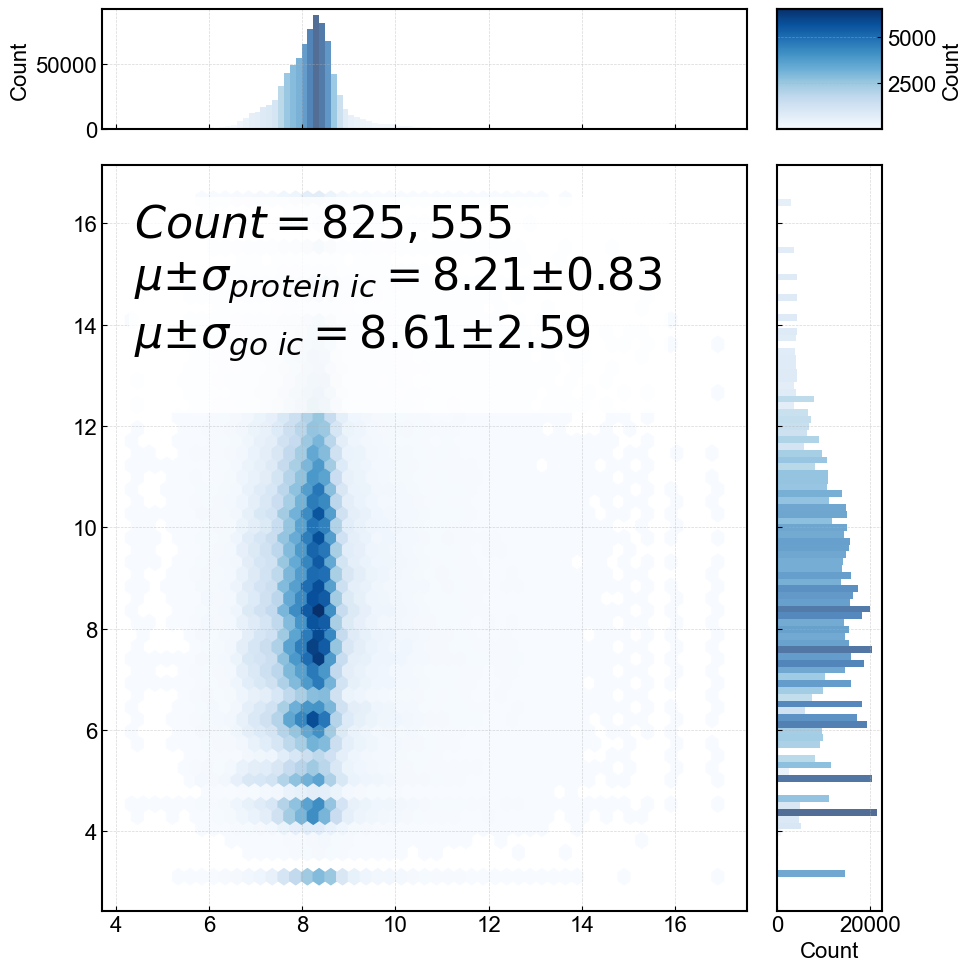

Creating plot for All position...


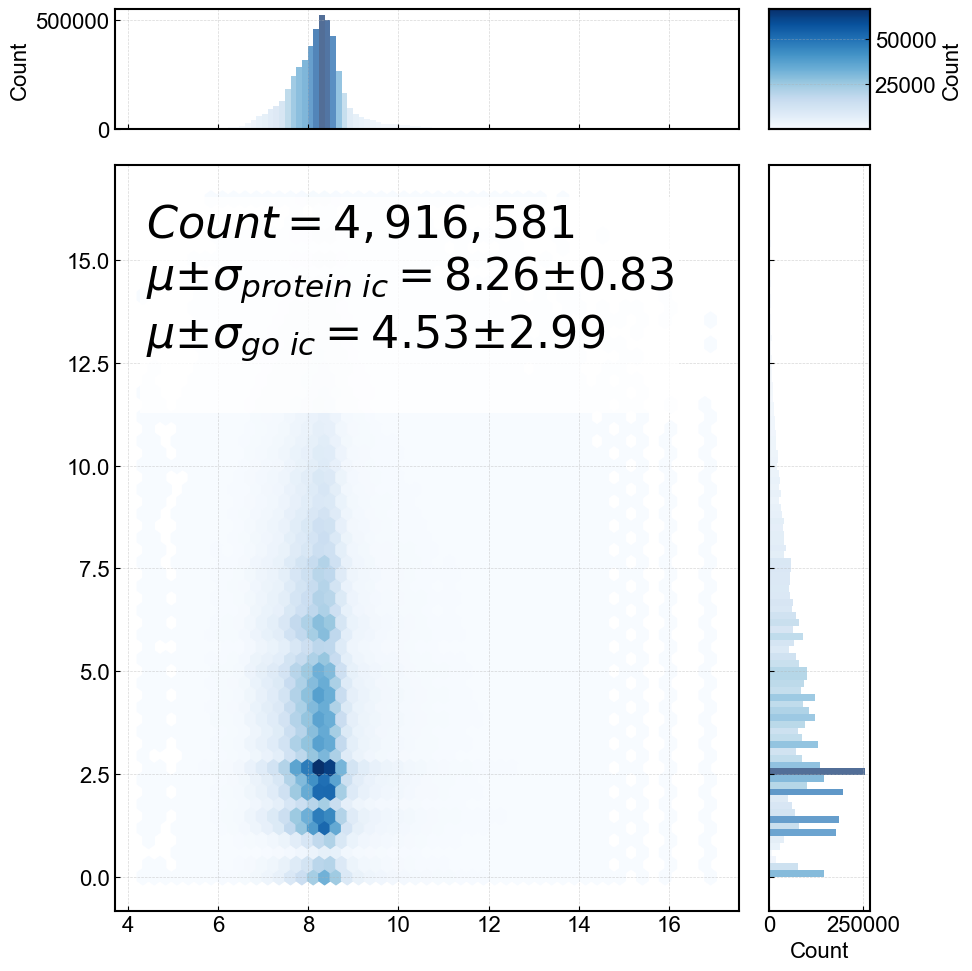

In [29]:
mpl.rcParams.update({
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 16
})

# Your existing data preparation code
prot_go_ic_df = prot_go_ic_df.replace([np.inf, -np.inf], np.nan).dropna()
merged_df = prot_go_ic_df.merge(term_count_ic[['gos', 'position']], on='gos', how='left')
positions = ['Shallow', 'Medium', 'Deep']
def create_hexbin_plot(data, title):
    """Create a hexbin plot with marginal histograms using colormap"""
    fig = plt.figure(figsize=(10, 10))
    n_sub = 6
    # Create main hexbin plot
    ax_main = plt.subplot2grid((n_sub, n_sub), (1, 0), colspan=n_sub-1, rowspan=n_sub-1)
    hb = ax_main.hexbin(data['p_ic'], data['g_ic'], gridsize=50, cmap='Blues', mincnt=1)
    # ax_main.set_xlabel('Protein IC')
    # ax_main.set_ylabel('GO IC')
    
    # Create marginal histograms with colormap
    ax_top = plt.subplot2grid((n_sub, n_sub), (0, 0), colspan=n_sub-1, sharex=ax_main)
    
    # Top histogram (p_ic) with colormap
    n_bins = 100
    counts_p, bins_p = np.histogram(data['p_ic'], bins=n_bins)
    bin_centers_p = (bins_p[:-1] + bins_p[1:]) / 2
    
    # Normalize counts for colormap
    norm_p = plt.Normalize(vmin=counts_p.min(), vmax=counts_p.max())
    colors_p = cm.Blues(norm_p(counts_p))
    
    ax_top.bar(bin_centers_p, counts_p, width=np.diff(bins_p), 
               color=colors_p, alpha=0.7, edgecolor='none')
    ax_top.set_ylabel('Count')
    ax_top.tick_params(labelbottom=False)
    
    # Right histogram (g_ic) with colormap
    ax_right = plt.subplot2grid((n_sub, n_sub), (1, n_sub-1), rowspan=n_sub-1, sharey=ax_main)
    
    counts_g, bins_g = np.histogram(data['g_ic'], bins=n_bins)
    bin_centers_g = (bins_g[:-1] + bins_g[1:]) / 2
    
    # Normalize counts for colormap
    norm_g = plt.Normalize(vmin=counts_g.min(), vmax=counts_g.max())
    # colors_g = cm.Reds(norm_g(counts_g))
    colors_g = cm.Blues(norm_g(counts_g))
    
    ax_right.barh(bin_centers_g, counts_g, height=np.diff(bins_g),
                  color=colors_g, alpha=0.7, edgecolor='none')
    ax_right.set_xlabel('Count')
    ax_right.tick_params(labelleft=False)
    
    # Add colorbar
    cbar_ax = plt.subplot2grid((n_sub, n_sub), (0, n_sub-1))
    plt.colorbar(hb, cax=cbar_ax, label='Count')
    
    # plt.suptitle(f'{title} (n={len(data):,})')
    plt.tight_layout()
    
    return fig
# Create hexbin plots for each position
print("Creating hexbin plots...")
for position in positions + ['All']:
    if position == 'All':
        data = merged_df
    else:
        data = merged_df[merged_df['position'] == position]
    
    if len(data) == 0:
        print(f"No data for {position} position")
        continue
    
    print(f"Creating plot for {position} position...")
    fig = create_hexbin_plot(data, f'{position} Position')

    # set boarders and grid
    axs = fig.get_axes()
    for ax in axs:
        # set to black and increase the width
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1.5)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_facecolor('white')
    
    # display the statistics on the plot  
       
    # Add statistics text to the plot
    # add italics to the text
    stats_text = (
        f"$ Count = {len(data):,} $\n"
        # f"$ Protein\ IC: [{data['p_ic'].min():.3f}, {data['p_ic'].max():.3f}] $\n"
        # f"$ GO\ IC: [{data['g_ic'].min():.3f}, {data['g_ic'].max():.3f}] $\n"
        f"$ \mu ± \sigma_{{protein\ ic}} = {data['p_ic'].mean():.2f} ± {data['p_ic'].std():.2f} $\n"
        f"$ \mu ± \sigma_{{go\ ic}} = {data['g_ic'].mean():.2f} ± {data['g_ic'].std():.2f} $\n"
        # f"$ Corr = {data['p_ic'].corr(data['g_ic'], method='spearman'):.3f} $"
    )
    # Get the main hexbin plot axis
    ax_main = axs[0]  # Main plot is the second axes object
    
    # Add text box in top right corner of main plot
    ax_main.text(0.05, 0.95, stats_text,
                transform=ax_main.transAxes,
                verticalalignment='top',
                horizontalalignment='left',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
                fontdict={'fontsize': 32},
                )

    plt.show()

    # saving plotting figures
    saving_root = P.Path("/data0/shaojiangyi/pprogo-flg-1/notebooks/perf_analysis/figures")
    file_name = "prot_go_ic_hexbin_1"
    saving_path = saving_root / f"{file_name}_{position}"
    fig.savefig(f"{saving_path}.svg", bbox_inches='tight')
    fig.savefig(f"{saving_path}.png", bbox_inches='tight', dpi=300)


# # Print summary statistics
# print("\nSummary Statistics:")
# print("=" * 50)